---
# <div align="center"> **COSC2793 | Machine Learning** </div>
# <div align="center"> **Assessment 1 - Melbourne Airbnb Listings** <div>
---

# **Introduction**

Online short-term rental platforms like Airbnb give local hosts the opportunity to rent out their rooms or entire properties to travelers. One of the main challenges hosts faces is deciding on the right nightly price. Setting the price too high can discourage potential guests and reduce bookings, while pricing too low may result in lost income. Since pricing is influenced by a range of factors—such as property features, location, available amenities, and host details—machine learning techniques can be used to analyze historical data and suggest a more appropriate and competitive price.

For Assessment 1, our task is to develop a machine learning model, predicting the price of an Airbnb listing in Melbourne based on the given attributes/features of the dataset. The machine learning models are limited from Week 1 – Week 4 of the course (COSC2793 – Computational Machine Learning), and that the workflow of the model must be justified, and documented in this report using data analysis, performance analysis, and/or knowledge from relevant literature.

We are tasked with evaluating at least three different models to determine which one is the MOST APPROPRIATE for this task. It is required that our report contains an explanation for our evaluation framework, including selecting appropriate performance measures for the task, and justification for our choices.


# **Dataset description**

The dataset, given in this assessment, contains the following features:
-	host_is_superhost
-	city
-	country
-	latitude: Uses the World Geodetic System (WGS84) projection for latitude and longitude.
-	longitude: Uses the World Geodetic System (WGS84) projection for latitude and longitude.
-	room_type
-	accommodates: The maximum capacity of the listing.
-	bathrooms: The number of bathrooms of the listing.
-	Bedrooms: The number of bed(s).
-	minimum_nights: Minimum number of night stay for the listing.
-	number_of_reviews: The number of reviews the listing has.
-	review_scores_rating
-	instant_bookable: Whether the guest can automatically book the listing without the host requiring accepting their booking request. An indicator of a commercial listing.
-	calculated_host_listings_count: The number of listings the host has in the current scrape, in the city/region geography.

The train_data.csv has an additional column which is:
-	price: Daily price in local currency (which in this case, is $AUD)


# **Objectives**

- **Primary goal:** The goal is to develop a machine learning model to predict the prices of an Airbnb listing.
- **Data preparation:**
    - Perform EDA, define relationship between features and make assumptions
- **Feature engineering:**
    - Implement feature engineering techniques e.g., feature scaling, one-hot encoding, etc.,
    -
- **Exploring machine learning models:**
    - Selecting and rationale Regression models
    - Train multiple models
- **Model Evaluation:**
    - Evaluation on models' metrics:
    - Implement K-fold validation technique, to ensure thorough models assessment
- **Model selection:**
    - Select the model based on the following aspects:
        

# **Getting started**

In [ ]:
# Installing modules and running .venv environment
!cd . # Change into run.sh directory
!bash run.sh # Run the run.sh file, installing key modules

# **Importing dataset and modules**

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
pd.options.display.max_rows = 4000

# Set a consistent style for plots
sns.set_theme(style="whitegrid")

# Load dataset
raw_train_file_path = "./dataset/airbnb_dataset_raw/train_data.csv"
raw_test_file_path = "./dataset/airbnb_dataset_raw/test_data.csv"

# Load dataframe and view datasets' heads
train_df = pd.read_csv(raw_train_file_path, delimiter=",")
test_df = pd.read_csv(raw_test_file_path, delimiter=",")

train_df.head()

,host_is_superhost,city,country,latitude,longitude,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,instant_bookable,calculated_host_listings_count
0,f,Kingston,Australia,-38.022565,145.098937,Entire home/apt,5,1.0,2.0,4.0,111,3,28,94.0,t,1
1,f,Yarra,Australia,-37.782125,144.988079,Entire home/apt,3,1.0,1.0,1.0,80,1,59,93.0,t,1
2,t,Port Phillip,Australia,-37.853710,144.981529,Entire home/apt,4,1.0,1.0,2.0,150,2,14,100.0,f,1
3,f,Glen Eira,Australia,-37.876393,145.036635,Entire home/apt,2,1.0,1.0,1.0,125,1,39,97.0,f,55
4,f,Melbourne,Australia,-37.810398,144.950113,Entire home/apt,3,1.0,1.0,2.0,79,3,7,97.0,t,1


In [6]:
test_df.head()

,host_is_superhost,city,country,latitude,longitude,room_type,accommodates,bathrooms,bedrooms,beds,minimum_nights,number_of_reviews,review_scores_rating,instant_bookable,calculated_host_listings_count
0,f,Moreland,Australia,-37.766505,144.980736,Private room,2,1.0,1.0,1.0,3,108,87.0,t,1
1,t,Port Phillip,Australia,-37.859755,144.977369,Entire home/apt,3,1.0,1.0,2.0,3,15,94.0,f,17
2,f,Port Phillip,Australia,-37.864530,144.992238,Private room,2,1.0,1.0,2.0,1,63,90.0,f,1
3,f,Darebin,Australia,-37.697294,145.000816,Private room,2,1.0,1.0,1.0,7,159,94.0,f,3
4,f,Melbourne,Australia,-37.810267,144.985920,Private room,2,1.0,1.0,1.0,1,3,93.0,f,1


In [9]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8586 entries, 0 to 8585
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   host_is_superhost               8586 non-null   str    
 1   city                            8586 non-null   str    
 2   country                         8586 non-null   str    
 3   latitude                        8586 non-null   float64
 4   longitude                       8586 non-null   float64
 5   room_type                       8586 non-null   str    
 6   accommodates                    8586 non-null   int64  
 7   bathrooms                       8586 non-null   float64
 8   bedrooms                        8586 non-null   float64
 9   beds                            8586 non-null   float64
 10  price                           8586 non-null   int64  
 11  minimum_nights                  8586 non-null   int64  
 12  number_of_reviews               8586 non-null

In [10]:
train_df.describe()

,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,calculated_host_listings_count
count,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000
mean,-37.825074,145.009374,3.559865,1.282320,1.533077,2.036222,139.771372,3.158747,27.946657,94.176101,7.427324
std,0.065145,0.130473,2.225801,0.557906,0.916369,1.544967,123.293376,20.788007,42.409812,8.471527,15.438001
min,-38.224427,144.531993,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,20.000000,1.000000
25%,-37.849202,144.957065,2.000000,1.000000,1.000000,1.000000,71.000000,1.000000,3.000000,92.000000,1.000000
50%,-37.816460,144.977004,3.000000,1.000000,1.000000,2.000000,115.000000,2.000000,11.000000,97.000000,1.000000
75%,-37.802849,145.008316,4.000000,1.500000,2.000000,2.000000,162.750000,3.000000,33.000000,100.000000,5.000000
max,-37.491059,145.760250,16.000000,9.000000,10.000000,18.000000,3000.000000,1000.000000,479.000000,100.000000,98.000000


In [11]:
# Dropping any duplicate rows (duplicate Airbnb listings)
train_df.drop_duplicates()

# Reset the training data frame
train_df = train_df.reset_index(drop=True)

# Check new data sizes
print(
    f"After removing duplicates, the dataset has {train_df.shape[0]} rows and {train_df.shape[1]} columns"
)

After removing duplicates, the dataset has 8586 rows and 16 columns


- From what we see, we noticed that there are **NO DUPLICATES** or **MISSING VALUES** in the provided dataset
- We can concluded that there are no imbalance in the dataset, and given that we are training **Linear Regression** models, which are:
    - Not able to handle missing values directly
    - And/or throw an error or produce incorrect assumptions of the dataset
    - No bias with duplicated data

# **Exploratory Data Analysis (EDA)**

Training set splits - Columns of numeric data distribution:


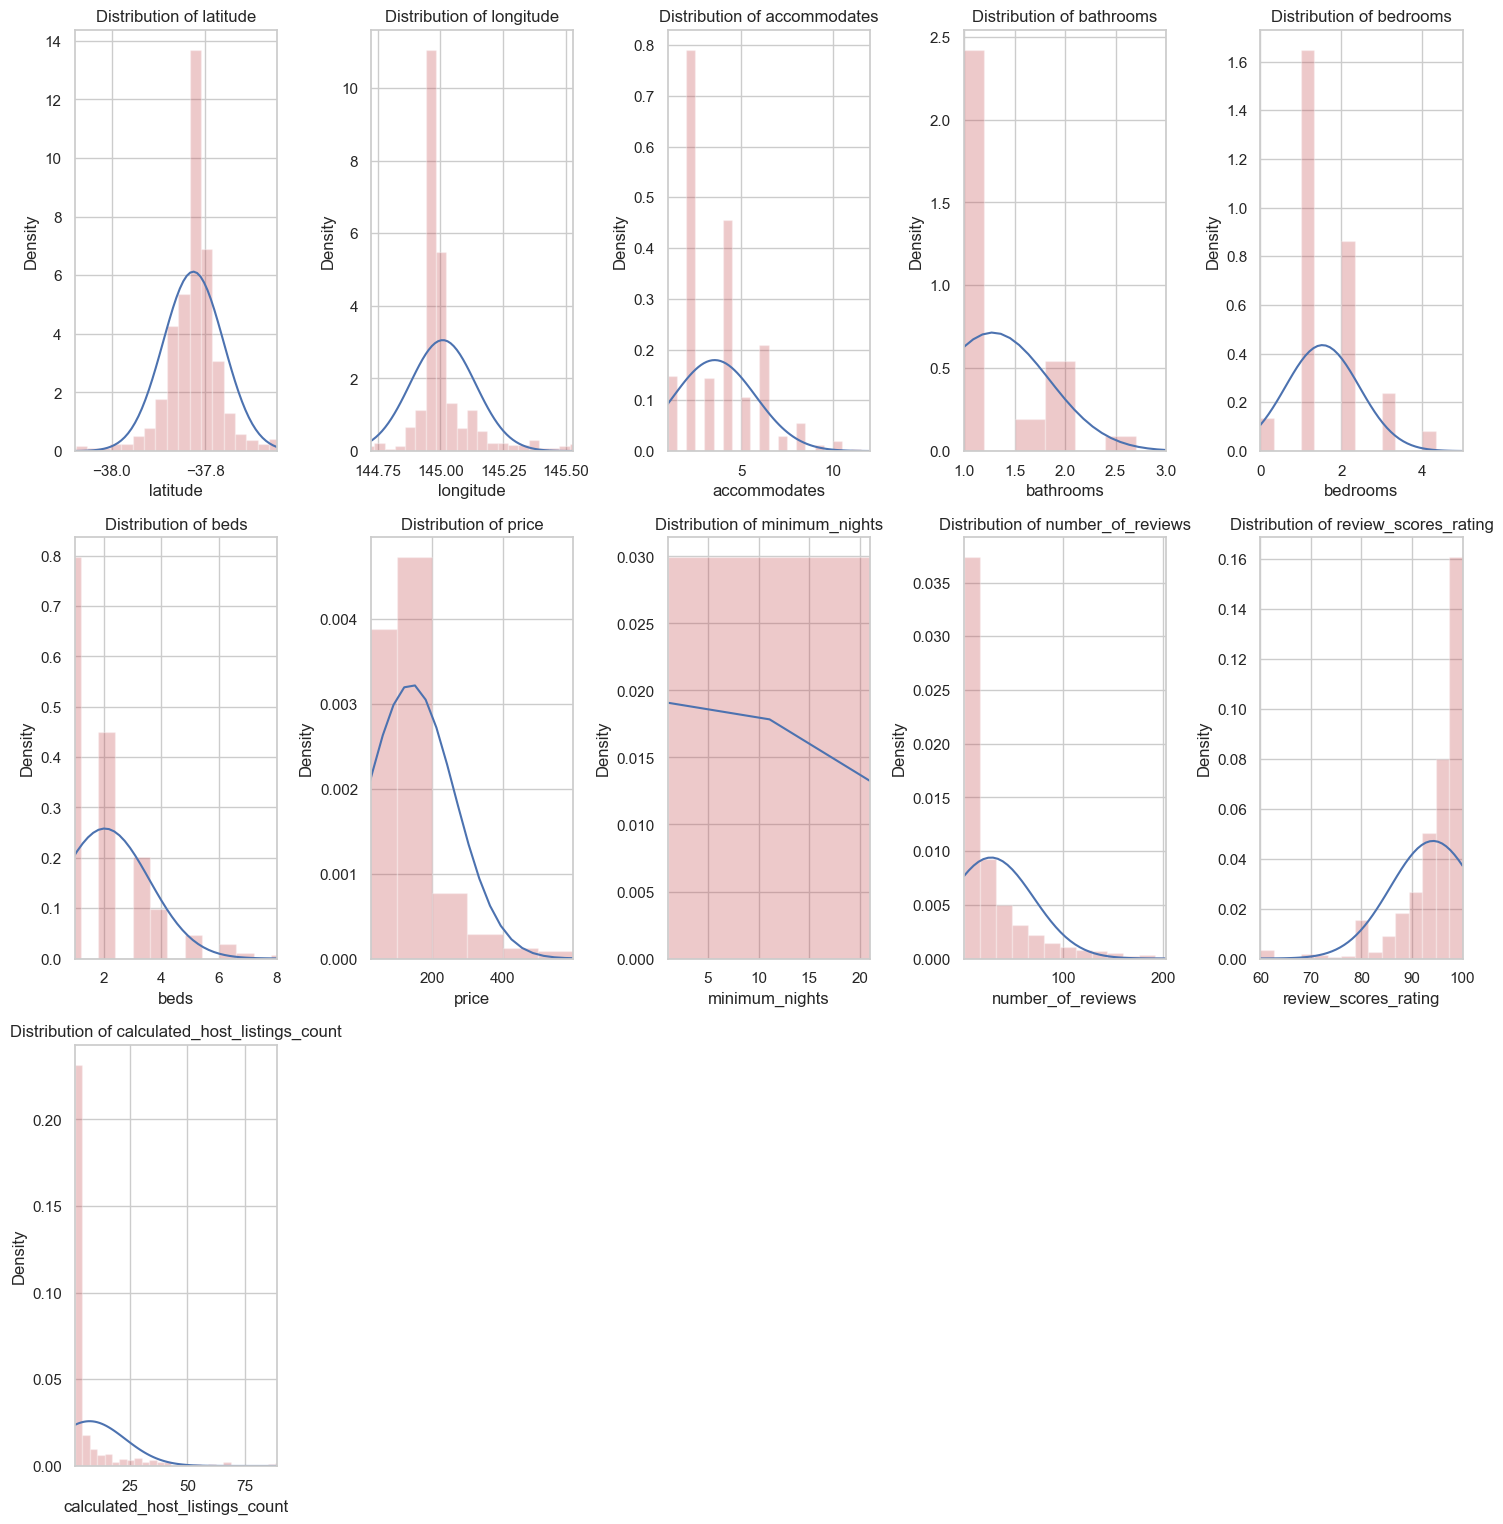

In [28]:
from scipy.stats import norm

# Iterate through integer data columns:
numeric_col_df = train_df.select_dtypes(include=['number'])
plt.figure(figsize=(15, 20))

print("Training set splits - Columns of numeric data distribution:")
for i, col in enumerate(numeric_col_df.columns):
    plt.subplot(4, 5, i + 1)

    # Select column data
    data = numeric_col_df[col].dropna()

    plt.hist(data, alpha=0.3, color="r", density=True, bins=30)

    # Calculate mean and std
    mu = data.mean()
    sigma = data.std()

    # Normal distribution curve
    x = np.linspace(data.min(), data.max(), 100)

    # Compute normal distribution
    y = norm.pdf(x, mu, sigma)

    # Plot the normal distribution graph
    plt.plot(x, y)

    # Zoom into 1st-99th percentile
    lower = data.quantile(0.01)
    upper = data.quantile(0.99)
    plt.xlim(lower, upper)

    plt.title("Distribution of " + col)
    plt.ylabel("Density")
    plt.xlabel(col)

plt.tight_layout()
plt.show()

- From what we can see, most features are distributed into Bell Curve shapes, or has a skewed left and/or right distribution. However, for the two columns of price, and minimum_nights, this is indicating the following features:
<br>
    **Price:**
    - Needs transformation -> log scaling
    - Otherwise Linear Regression models will perform poorly
    **=> Rationale:** This is because, as linear regression models train on this data, improper scaling of price could lead to wrong assumptions made, and prediction could be off-the-mark. Skewness like this could cause errors to Linear Regression models as outliers (either too large or too small) could lead to it relying/focusing on those data too much.
    Log transformation allow the feature to reduce skewness, compressing larger values into smaller values, and makes distribution more normal.

    **minimum_nights:**
    - Better as a categorical feature
    - Or a grouped feature (e.g., 1 - 3, 4 - 7)
    **=> Rationale:** As for minimum_nights, if we look at it semantically, the values are basically *categorical features*, and **not a numeric relationship**. The effects of this column is non-linear and grouped, although it is numeric data values, grouping minimum_nights can reflect realistic pricing and meaning of this feature.
</br>
- As for other features such as, cities, room_type, these values can be treated as a categorical features, as using that, we can **classify** Airbnbs, into possible price ranges regarding to their types. For example, a room_type such as a Private home, could have higher price ranges compared to Entire home/apt.
